# Notebook 4 - Modelado y segmentacion territorial

Este cuaderno desarrolla la fase de modelado del pilar de Analisis del Dato a partir de la tabla municipal agregada generada en el `Notebook 3`.

A diferencia del cuaderno anterior, centrado en el analisis descriptivo y la construccion de indicadores, aqui el objetivo es identificar grupos de municipios con perfiles climaticos y territoriales similares mediante tecnicas de segmentacion no supervisada.

La entrada principal del notebook es:

`DATA/PROCESSED/dataset_cv_municipios_analisis_municipal.csv`

El enfoque adoptado en esta fase no pretende todavia predecir siniestros reales, sino detectar patrones municipales de riesgo relativo, intensidad climatica y vulnerabilidad territorial que puedan resultar utiles para la interpretacion posterior y para el Analisis de Negocio.


## 0. Configuracion inicial

En este bloque se cargan las librerias necesarias y se definen las rutas de trabajo. El notebook parte de la salida analitica municipal ya construida, por lo que no repite el proceso ETL ni el analisis exploratorio anterior.

Ademas, se preparan las rutas para posibles salidas de modelado, visualizacion y exportacion de resultados.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "DATA"
PROC = DATA / "PROCESSED"
EXT = DATA / "EXTERNAL"
OUT = ROOT / "output"
MAPS = OUT / "maps"

ANALYTIC_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_analisis_municipal.csv"
MUNICIPIOS_GEO_FILE = EXT / "municipios_cv.geojson"
SEGMENTED_MUNICIPAL_FILE = PROC / "dataset_cv_municipios_segmentado.csv"

MODEL_OUT = OUT / "modelado"
MODEL_OUT.mkdir(parents=True, exist_ok=True)
MAPS.mkdir(parents=True, exist_ok=True)

print("Dataset municipal analitico:", ANALYTIC_MUNICIPAL_FILE)
print("Existe:", ANALYTIC_MUNICIPAL_FILE.exists())
print("Geometria municipal disponible:", MUNICIPIOS_GEO_FILE.exists())
print("Directorio de salida:", MODEL_OUT)
print("Salida segmentada prevista:", SEGMENTED_MUNICIPAL_FILE)


Dataset municipal analitico: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_analisis_municipal.csv
Existe: True
Geometria municipal disponible: True
Directorio de salida: C:\Users\gonza\OneDrive\tfg\output\modelado
Salida segmentada prevista: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_segmentado.csv


## 1. Objetivo analitico del modelado y carga de la base municipal

El objetivo de esta fase es identificar grupos de municipios con perfiles climaticos y territoriales similares a partir de la tabla agregada construida en el `Notebook 3`. Dado que no se dispone de datos reales de siniestralidad para entrenar un modelo supervisado, el enfoque adoptado se basa en tecnicas de segmentacion no supervisada.

En consecuencia, el modelado no pretende predecir siniestros, sino detectar patrones municipales de riesgo relativo, intensidad climatica y vulnerabilidad territorial. Esta aproximacion permite comparar municipios, construir tipologias y preparar una lectura posterior orientada a negocio.

Antes de seleccionar variables y entrenar modelos, se carga la base municipal analitica y se comprueba que conserva la estructura esperada.


In [2]:
df_mun = pd.read_csv(ANALYTIC_MUNICIPAL_FILE)

print("Shape:", df_mun.shape)
print("Municipios unicos:", df_mun["municipio"].nunique())
print("Columnas:", len(df_mun.columns))
print("Columnas principales disponibles:")

key_cols = [
    "municipio",
    "precip_p99",
    "dias_precip_extrema",
    "temp_p95",
    "dias_calor_intenso",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "altitud_m",
]

print([col for col in key_cols if col in df_mun.columns])

display(df_mun.head())


Shape: (542, 42)
Municipios unicos: 542
Columnas: 42
Columnas principales disponibles:
['municipio', 'precip_p99', 'dias_precip_extrema', 'temp_p95', 'dias_calor_intenso', 'viento_p95', 'densidad_poblacion', 'mayores_65_pct', 'renta_media_hogar', 'altitud_m']


,municipio,CODNUT2,CODNUT3,precip_media_diaria,precip_max_dia,precip_p95,precip_p99,dias_precip_intensa,dias_precip_extrema,temp_media_periodo,temp_max_media,temp_max_abs,temp_p95,dias_calor_intenso,temp_min_abs,viento_medio_periodo,viento_max_abs,viento_p95,dias_viento_intenso,amplitud_termica_media,lon,lat,dist_metros,area_km2,cod_ine,poblacion_total,densidad_poblacion,mayores_65_pct,menores_16_pct,indice_envejecimiento,renta_media_hogar,altitud_m,tramo_altitud,score_precip,score_calor,score_viento,score_peligro_climatico,score_densidad,score_mayores,score_renta_baja,score_vulnerabilidad,score_riesgo_preliminar
0,Ademuz,ES52,ES523,1.459790,33.931183,8.618695,18.368174,105,6,12.317326,17.969816,37.645905,32.069465,60,-9.880951,2.354678,9.956327,6.782720,78,10.909306,-1.2,40.1,5806.682345,100.2900,46001,1015.0,10.12,26.80,11.82,226.67,27809.0,907.0,800+ m,0.079986,0.188119,0.335031,0.201045,0.000388,0.437358,0.853748,0.430498,0.292826
1,Ador,ES52,ES523,2.102830,143.414780,11.106972,37.833611,138,38,17.895431,21.608291,39.722076,31.999384,68,1.046295,3.106088,13.624233,7.682318,179,7.251112,-0.2,38.9,2485.383043,13.8364,46002,1755.0,126.84,20.42,11.36,179.70,31572.0,79.0,<=200 m,0.889841,0.214521,0.554274,0.552879,0.005191,0.275880,0.763319,0.348130,0.470979
2,Agost,ES52,ES521,1.094086,75.414550,5.610108,18.520694,75,11,18.075257,22.611731,39.302155,32.961835,97,-0.357025,2.732337,13.176444,7.184352,117,8.828438,-0.6,38.4,6996.059580,66.6538,3002,5225.0,78.39,20.27,13.84,146.47,30407.0,181.0,<=200 m,0.086332,0.310231,0.432913,0.276492,0.003197,0.272083,0.791315,0.355532,0.308108
3,Agres,ES52,ES521,1.826327,106.037970,9.551134,31.017301,123,28,16.650944,22.090261,42.157623,34.419501,176,-3.486420,1.976098,9.044077,5.725050,22,10.334956,-0.5,38.8,2075.930152,25.8457,3003,623.0,24.10,24.80,11.36,218.31,31440.0,756.0,600-800 m,0.606250,0.570957,0.077263,0.418157,0.000964,0.386738,0.766491,0.384731,0.404786
4,Agullent,ES52,ES523,1.690449,98.432850,9.223645,28.305807,113,25,16.429414,22.035266,42.036530,34.757147,200,-3.988373,1.995531,9.247415,5.912659,29,10.584102,-0.6,38.8,5559.636342,16.2440,46004,2438.0,150.09,21.43,12.46,172.04,31085.0,556.0,400-600 m,0.493439,0.650165,0.122986,0.422197,0.006147,0.301443,0.775022,0.360871,0.397666


## 2. Seleccion de variables para la segmentacion

La segmentacion se construye a partir de un conjunto reducido de variables climaticas y territoriales que representan dimensiones relevantes del problema. El objetivo no es incluir todas las columnas disponibles, sino seleccionar aquellas que aportan informacion interpretable para diferenciar municipios en terminos de peligro climatico, exposicion y vulnerabilidad.

En el bloque climatico se combinan indicadores de precipitacion extrema, calor intenso y viento fuerte, mientras que en el bloque territorial se incorporan variables asociadas a densidad de poblacion, envejecimiento, renta y altitud. Aunque algunas variables climaticas presentan correlaciones elevadas, se mantienen de forma deliberada porque no representan exactamente la misma dimension: los percentiles aproximan intensidad y los recuentos de dias aproximan frecuencia. Esta seleccion busca un equilibrio entre capacidad descriptiva, interpretabilidad y control razonable de redundancias.

In [3]:
model_features = [
    "precip_p99",
    "dias_precip_extrema",
    "temp_p95",
    "dias_calor_intenso",
    "viento_p95",
    "densidad_poblacion",
    "mayores_65_pct",
    "renta_media_hogar",
    "altitud_m",
]

print("Variables seleccionadas para segmentacion:")
for col in model_features:
    print("-", col)

display(df_mun[model_features].describe().T)

print("Correlaciones entre variables seleccionadas:")
display(df_mun[model_features].corr(numeric_only=True).round(2))

Variables seleccionadas para segmentacion:
- precip_p99
- dias_precip_extrema
- temp_p95
- dias_calor_intenso
- viento_p95
- densidad_poblacion
- mayores_65_pct
- renta_media_hogar
- altitud_m


,count,mean,std,min,25%,50%,75%,max
precip_p99,542.0,26.927875,5.382713,16.445655,23.357834,26.765683,29.846917,40.481348
dias_precip_extrema,542.0,21.920664,8.175929,5.000000,16.000000,21.000000,28.000000,41.000000
temp_p95,542.0,32.880859,1.551139,28.335553,31.729986,32.938959,34.163996,36.000543
dias_calor_intenso,542.0,109.605166,71.350680,3.000000,50.000000,101.000000,164.000000,306.000000
viento_p95,542.0,6.972567,0.719757,5.408023,6.516475,6.907734,7.409866,9.511220
densidad_poblacion,542.0,580.056642,2055.248495,0.680000,15.990000,87.810000,397.387500,24305.560000
mayores_65_pct,542.0,24.904244,7.000727,9.520000,19.812500,23.200000,29.395000,49.030000
renta_media_hogar,534.0,31774.187266,4591.499603,21723.000000,29345.500000,31407.000000,33680.750000,63336.000000
altitud_m,542.0,384.656827,327.369029,-2.000000,81.000000,328.000000,621.750000,1374.000000


Correlaciones entre variables seleccionadas:


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
precip_p99,1.00,0.98,-0.16,-0.17,0.01,-0.09,0.08,0.10,-0.12
dias_precip_extrema,0.98,1.00,-0.18,-0.18,0.03,-0.11,0.11,0.07,-0.09
temp_p95,-0.16,-0.18,1.00,0.97,-0.35,0.04,-0.25,-0.01,-0.26
dias_calor_intenso,-0.17,-0.18,0.97,1.00,-0.32,0.01,-0.22,-0.06,-0.24
viento_p95,0.01,0.03,-0.35,-0.32,1.00,0.14,-0.07,-0.00,-0.29
densidad_poblacion,-0.09,-0.11,0.04,0.01,0.14,1.00,-0.23,0.20,-0.27
mayores_65_pct,0.08,0.11,-0.25,-0.22,-0.07,-0.23,1.00,-0.39,0.51
renta_media_hogar,0.10,0.07,-0.01,-0.06,-0.00,0.20,-0.39,1.00,-0.29
altitud_m,-0.12,-0.09,-0.26,-0.24,-0.29,-0.27,0.51,-0.29,1.00


## 3. Preparacion del dataset para modelado

Antes de aplicar tecnicas de segmentacion, es necesario preparar la matriz de variables que utilizara el modelo. Esta fase incluye la comprobacion de valores nulos, la construccion de la matriz numerica final y la estandarizacion de las variables.

La estandarizacion resulta especialmente importante porque las variables seleccionadas se expresan en escalas muy distintas. Sin este paso, magnitudes como `densidad_poblacion`, `renta_media_hogar` o `altitud_m` dominarian artificialmente la segmentacion frente a otras variables climaticas.


In [4]:
X_raw = df_mun[model_features].copy()

print("Shape matriz original:", X_raw.shape)
print("Nulos por variable:")
display(X_raw.isna().sum().to_frame("nulos"))

# Imputacion simple para no perder municipios en esta fase exploratoria.
X_filled = X_raw.fillna(X_raw.median(numeric_only=True))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

X_scaled = pd.DataFrame(X_scaled, columns=model_features, index=df_mun.index)

print("Shape matriz escalada:", X_scaled.shape)
display(X_scaled.head())


Shape matriz original: (542, 9)
Nulos por variable:


,nulos
precip_p99,0
dias_precip_extrema,0
temp_p95,0
dias_calor_intenso,0
viento_p95,0
densidad_poblacion,0
mayores_65_pct,0
renta_media_hogar,8
altitud_m,0


Shape matriz escalada: (542, 9)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
0,-1.591690,-1.949059,-0.523579,-0.695873,-0.264010,-0.277564,0.271044,-0.869622,1.597053
1,2.027938,1.968484,-0.568801,-0.583647,0.987008,-0.220720,-0.641131,-0.043213,-0.934539
2,-1.563328,-1.336943,0.052252,-0.176828,0.294516,-0.244316,-0.662578,-0.299064,-0.622676
3,0.760435,0.744252,0.992859,0.931402,-1.734849,-0.270756,-0.014904,-0.072202,1.135374
4,0.256229,0.376982,1.210736,1.268080,-1.473953,-0.209397,-0.496727,-0.150165,0.523878


## 4. Primer modelo: KMeans y seleccion del numero de clusters

Como primer enfoque de segmentacion se aplica `KMeans`, una tecnica no supervisada que busca agrupar observaciones en funcion de su proximidad en el espacio de variables. En este contexto, el objetivo es identificar conjuntos de municipios con perfiles climaticos y territoriales similares.

Dado que `KMeans` requiere fijar previamente el numero de clusters, se prueban varios valores de `k` y se comparan mediante distintas metricas de adecuacion. Esta fase no persigue optimizar un unico criterio matematico de forma aislada, sino encontrar una segmentacion que resulte razonable tanto desde el punto de vista cuantitativo como interpretativo.


In [5]:
k_values = range(2, 7)
kmeans_results = []

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)

    kmeans_results.append(
        {
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(X_scaled, labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        }
    )

df_kmeans_eval = pd.DataFrame(kmeans_results)
display(df_kmeans_eval)


,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,3873.036370,0.210928,1.810480,140.117548
1,3,3272.912080,0.227915,1.533964,132.167068
2,4,2830.368400,0.236068,1.414444,129.738800
3,5,2452.175761,0.253157,1.272137,132.807325
4,6,2097.641731,0.261107,1.123127,142.090235


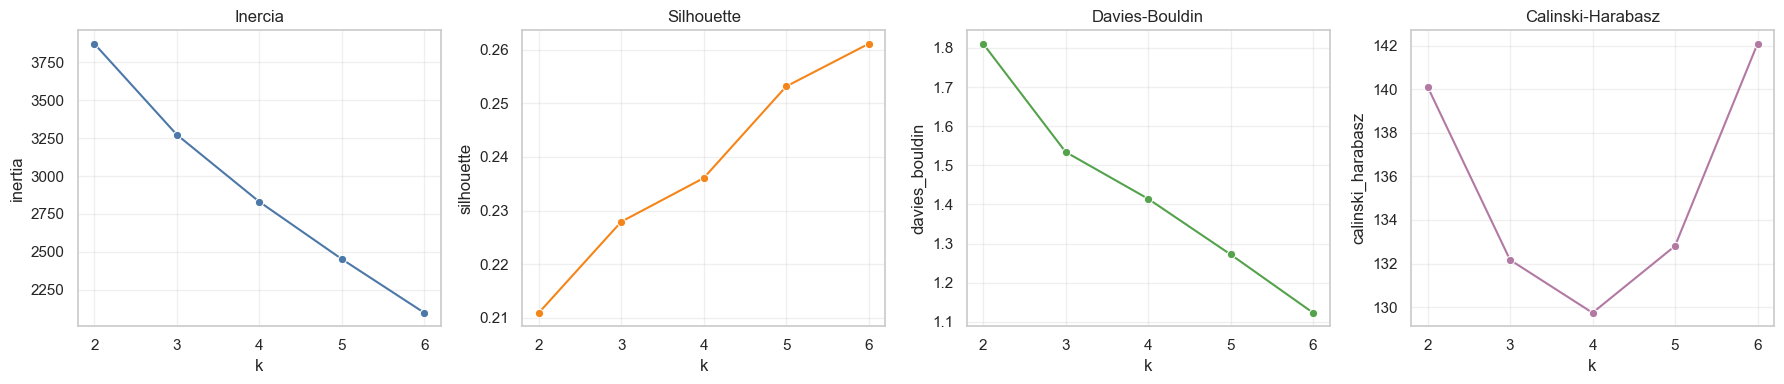

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

sns.lineplot(data=df_kmeans_eval, x="k", y="inertia", marker="o", ax=axes[0], color="#4c78a8")
axes[0].set_title("Inercia")

sns.lineplot(data=df_kmeans_eval, x="k", y="silhouette", marker="o", ax=axes[1], color="#f58518")
axes[1].set_title("Silhouette")

sns.lineplot(data=df_kmeans_eval, x="k", y="davies_bouldin", marker="o", ax=axes[2], color="#54a24b")
axes[2].set_title("Davies-Bouldin")

sns.lineplot(data=df_kmeans_eval, x="k", y="calinski_harabasz", marker="o", ax=axes[3], color="#b279a2")
axes[3].set_title("Calinski-Harabasz")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


La seleccion del numero de clusters se apoya en varios criterios complementarios. En general, valores altos de `silhouette` y `calinski_harabasz`, junto con valores bajos de `davies_bouldin`, sugieren segmentaciones mas consistentes. No obstante, la eleccion final de `k` debe equilibrar calidad estadistica e interpretabilidad territorial.

En los resultados obtenidos, `k=6` ofrece las mejores metricas internas, pero genera un cluster muy pequeno que reduce la estabilidad e interpretabilidad territorial del modelo. Por ello, se selecciona `k=5`, que mantiene metricas favorables y reparte los municipios en grupos mas equilibrados y utiles para el analisis posterior.

## 5. Ajuste final de KMeans e interpretacion de clusters

Una vez comparados varios valores posibles de `k`, se selecciona una configuracion final de `KMeans` para analizar con mayor detalle los perfiles resultantes. A partir de esta segmentacion, se asigna a cada municipio un cluster y se estudian las diferencias medias entre grupos en las variables climaticas y territoriales seleccionadas.

El objetivo de esta fase no es solo obtener una particion del dataset, sino interpretar el significado de cada cluster y valorar si la segmentacion resulta util para distinguir tipologias municipales con implicaciones analiticas y territoriales.


In [7]:
k_final = 5

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=20)
df_mun["cluster_kmeans"] = kmeans_final.fit_predict(X_scaled)

print("Numero de clusters:", k_final)
print("Tamano de cada cluster:")
display(df_mun["cluster_kmeans"].value_counts().sort_index().to_frame("municipios"))

Numero de clusters: 5
Tamano de cada cluster:


,municipios
cluster_kmeans,
0,104
1,85
2,105
3,104
4,144


In [8]:
cluster_profile = (
    df_mun.groupby("cluster_kmeans")[model_features]
    .mean()
    .round(2)
)

display(cluster_profile)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
cluster_kmeans,,,,,,,,,
0,32.51,29.82,34.50,183.56,6.43,184.85,23.82,32209.22,276.70
1,31.96,30.15,31.57,49.84,8.07,362.23,24.72,31269.49,244.48
2,23.93,16.80,32.62,88.09,7.17,2224.62,18.85,36631.25,123.29
3,20.70,12.74,34.37,185.02,6.93,231.72,25.07,29287.14,436.31
4,26.60,21.72,31.60,52.70,6.60,46.48,30.09,29990.33,698.65


In [9]:
cluster_profile_scaled = (
    df_mun.groupby("cluster_kmeans")[model_features]
    .mean()
)

cluster_profile_scaled = (
    (cluster_profile_scaled - cluster_profile_scaled.mean())
    / cluster_profile_scaled.std()
).round(2)

display(cluster_profile_scaled)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
cluster_kmeans,,,,,,,,,
0,1.05,0.98,1.09,1.06,-0.95,-0.47,-0.17,0.11,-0.36
1,0.94,1.02,-0.95,-0.91,1.61,-0.27,0.05,-0.21,-0.50
2,-0.63,-0.70,-0.22,-0.35,0.19,1.78,-1.42,1.65,-1.05
3,-1.26,-1.23,1.00,1.08,-0.17,-0.42,0.14,-0.90,0.36
4,-0.11,-0.07,-0.93,-0.87,-0.68,-0.62,1.39,-0.65,1.55


In [10]:
display(
    df_mun[
        ["municipio", "cluster_kmeans"] + model_features
    ]
    .sort_values(["cluster_kmeans", "municipio"])
    .head(30)
)


,municipio,cluster_kmeans,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
3,Agres,0,31.017301,28,34.419501,176,5.725050,24.10,24.80,31440.0,756.0
4,Agullent,0,28.305807,25,34.757147,200,5.912659,150.09,21.43,31085.0,556.0
5,Aielo de Malferit,0,31.602399,28,35.521466,241,6.165055,172.88,18.67,34914.0,382.0
6,Aielo de Rugat,0,40.481348,41,33.088251,109,6.647643,20.71,35.40,43758.0,409.0
10,Albaida,0,31.017301,28,34.419501,176,5.725050,179.02,20.89,32317.0,756.0
12,Albalat de la Ribera,0,28.848063,25,34.167437,170,7.321437,243.98,20.49,30619.0,11.0
16,Alberic,0,29.846917,28,34.827740,201,6.793810,414.06,18.79,31085.0,24.0
23,Alcoi/Alcoy,0,27.612105,24,33.553741,128,5.571627,472.83,22.07,31566.0,794.0
25,Alcosser,0,34.254530,29,33.661932,135,5.655909,59.92,21.29,36765.0,364.0
28,Alcàntera de Xúquer,0,30.225485,25,35.470624,231,6.749098,428.48,20.53,30078.0,160.0


La solucion final con `k=5` permite observar grupos de municipios con combinaciones diferenciadas de precipitacion extrema, calor, viento, altitud, densidad y vulnerabilidad social. La lectura de los perfiles medios facilita interpretar cada cluster no solo como una etiqueta numerica, sino como una tipologia territorial con caracteristicas climaticas y socioeconomicas propias.

En esta fase, la utilidad principal del modelo reside en su capacidad para resumir la heterogeneidad municipal en un numero reducido de grupos interpretables, lo que prepara el terreno para su representacion espacial y su comparacion con otros enfoques de segmentacion.

## 6. Representacion espacial e interpretacion territorial de KMeans

Una vez asignado un cluster a cada municipio, resulta necesario trasladar la segmentacion al espacio geografico para comprobar si los grupos obtenidos muestran coherencia territorial. Esta representacion permite detectar si los clusters aparecen de forma dispersa o si, por el contrario, tienden a concentrarse en determinadas zonas con perfiles climaticos y territoriales compartidos.

La lectura espacial del modelo es especialmente relevante en este TFG, ya que el objetivo no es solo agrupar municipios desde un punto de vista estadistico, sino interpretar si esas agrupaciones pueden entenderse como tipologias territoriales de riesgo relativo.


In [11]:
gdf_mun = gpd.read_file(MUNICIPIOS_GEO_FILE)

gdf_kmeans = gdf_mun.merge(
    df_mun[["municipio", "CODNUT2", "CODNUT3", "cluster_kmeans"] + model_features],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

print("Municipios en geometria:", len(gdf_mun))
print("Municipios con cluster:", gdf_kmeans["cluster_kmeans"].notna().sum())
display(gdf_kmeans[["municipio", "cluster_kmeans"]].head())


Municipios en geometria: 542
Municipios con cluster: 542


,municipio,cluster_kmeans
0,l'Atzúbia,1
1,Agost,3
2,Agres,0
3,Aigües,2
4,Albatera,3


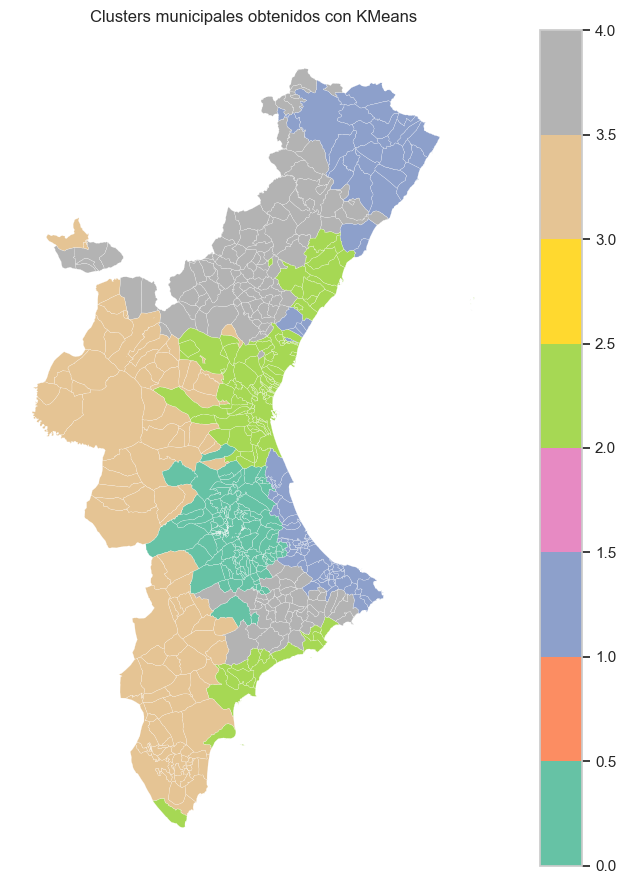

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_kmeans.plot(
    column="cluster_kmeans",
    cmap="Set2",
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)

ax.set_title("Clusters municipales obtenidos con KMeans")
ax.axis("off")
plt.tight_layout()
plt.show()


In [13]:
cluster_summary = (
    df_mun.groupby("cluster_kmeans")
    .agg(
        municipios=("municipio", "count"),
        precip_p99=("precip_p99", "mean"),
        dias_precip_extrema=("dias_precip_extrema", "mean"),
        temp_p95=("temp_p95", "mean"),
        dias_calor_intenso=("dias_calor_intenso", "mean"),
        viento_p95=("viento_p95", "mean"),
        densidad_poblacion=("densidad_poblacion", "mean"),
        mayores_65_pct=("mayores_65_pct", "mean"),
        renta_media_hogar=("renta_media_hogar", "mean"),
        altitud_m=("altitud_m", "mean"),
    )
    .round(2)
)

display(cluster_summary)


,municipios,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
cluster_kmeans,,,,,,,,,,
0,104,32.51,29.82,34.50,183.56,6.43,184.85,23.82,32209.22,276.70
1,85,31.96,30.15,31.57,49.84,8.07,362.23,24.72,31269.49,244.48
2,105,23.93,16.80,32.62,88.09,7.17,2224.62,18.85,36631.25,123.29
3,104,20.70,12.74,34.37,185.02,6.93,231.72,25.07,29287.14,436.31
4,144,26.60,21.72,31.60,52.70,6.60,46.48,30.09,29990.33,698.65


La representacion espacial permite valorar si los clusters identificados por `KMeans` presentan continuidad o concentracion territorial, algo especialmente importante en un problema geoespacial como el del presente TFG. Si los grupos muestran patrones espaciales recognoscibles, la segmentacion gana interpretabilidad y utilidad para fases posteriores de analisis y negocio.

Ademas, la tabla resumen por cluster facilita traducir cada grupo a un perfil territorial concreto, combinando intensidad climatica, vulnerabilidad demografica y contexto socioeconomico. Esta lectura resulta clave para pasar de una clasificacion puramente estadistica a una interpretacion aplicada del territorio.


## 7. Segundo modelo: Agglomerative Clustering

Como contraste frente a `KMeans`, se aplica un segundo enfoque de segmentacion no supervisada basado en `Agglomerative Clustering`. A diferencia de `KMeans`, este metodo no parte de centroides, sino de una logica jerarquica que va agrupando observaciones en funcion de su proximidad.

El objetivo de este segundo modelo no es reemplazar automaticamente al primero, sino comprobar si la estructura municipal detectada resulta estable bajo un enfoque alternativo y si los grupos obtenidos mantienen una interpretacion territorial razonable.


In [14]:
agg_model = AgglomerativeClustering(n_clusters=k_final)
df_mun["cluster_agg"] = agg_model.fit_predict(X_scaled)

print("Numero de clusters:", k_final)
print("Tamaño de cada cluster:")
display(df_mun["cluster_agg"].value_counts().sort_index().to_frame("municipios"))


Numero de clusters: 5
Tamaño de cada cluster:


,municipios
cluster_agg,
0,86
1,167
2,129
3,77
4,83


In [15]:
agg_labels = df_mun["cluster_agg"]

agg_metrics = pd.DataFrame(
    [
        {
            "modelo": "Agglomerative",
            "silhouette": silhouette_score(X_scaled, agg_labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, agg_labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, agg_labels),
        }
    ]
)

display(agg_metrics)


,modelo,silhouette,davies_bouldin,calinski_harabasz
0,Agglomerative,0.213414,1.449691,111.732641


In [16]:
agg_profile = (
    df_mun.groupby("cluster_agg")[model_features]
    .mean()
    .round(2)
)

display(agg_profile)


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
cluster_agg,,,,,,,,,
0,23.46,16.01,33.28,117.72,7.22,2529.49,18.72,36069.29,109.34
1,25.40,19.48,31.90,59.86,6.56,165.21,26.71,31034.89,554.31
2,33.32,31.21,34.05,161.71,6.69,288.65,23.03,32632.32,247.00
3,20.23,12.32,34.62,201.22,6.96,256.39,26.01,28819.53,418.30
4,29.89,27.42,31.00,35.33,7.98,148.03,29.57,30166.66,511.31


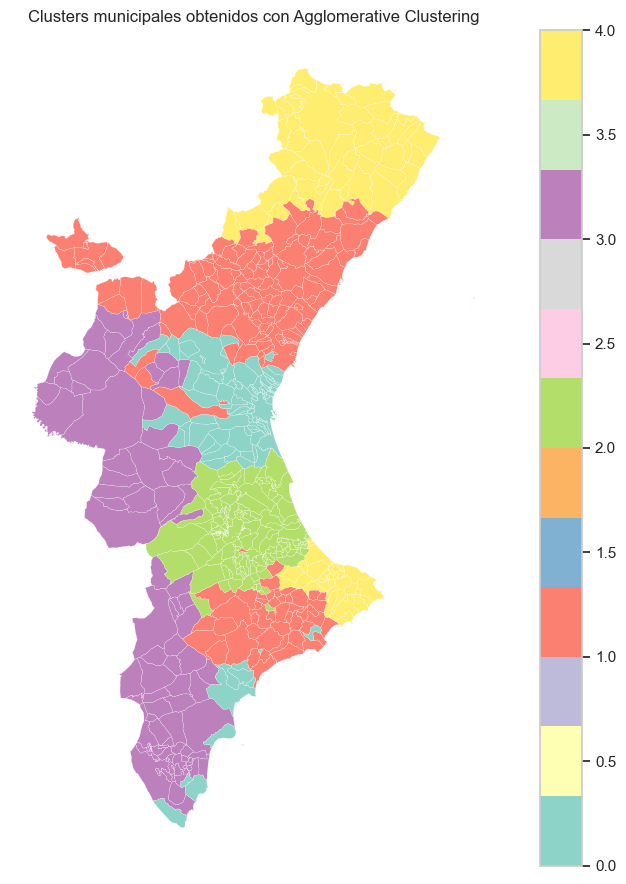

In [17]:
gdf_agg = gdf_mun.merge(
    df_mun[["municipio", "CODNUT2", "CODNUT3", "cluster_agg"]],
    on=["municipio", "CODNUT2", "CODNUT3"],
    how="left",
)

fig, ax = plt.subplots(1, 1, figsize=(9, 9))

gdf_agg.plot(
    column="cluster_agg",
    cmap="Set3",
    legend=True,
    ax=ax,
    linewidth=0.15,
    edgecolor="white",
    missing_kwds={"color": "lightgrey", "label": "Sin datos"},
)

ax.set_title("Clusters municipales obtenidos con Agglomerative Clustering")
ax.axis("off")
plt.tight_layout()
plt.show()

El segundo modelo permite comprobar si la segmentacion territorial observada con `KMeans` se mantiene bajo un enfoque jerarquico alternativo. La comparacion entre ambos resultados resulta util para evaluar la estabilidad de los patrones municipales detectados y para valorar que modelo ofrece una lectura mas interpretable del territorio.

En esta fase, el interes no reside unicamente en la calidad numerica de las metricas, sino tambien en la capacidad del modelo para generar grupos coherentes desde el punto de vista geografico, climatico y territorial, tanto en los perfiles medios como en su distribucion espacial.

## 8. Comparacion entre modelos y seleccion del enfoque mas util

Una vez aplicados `KMeans` y `Agglomerative Clustering`, el siguiente paso consiste en comparar ambos enfoques tanto desde el punto de vista cuantitativo como interpretativo. Para ello, se utilizan las metricas de adecuacion disponibles y se contrastan tambien la distribucion de municipios por cluster y la coherencia territorial de los grupos obtenidos.

El objetivo no es identificar un modelo matematicamente perfecto, sino seleccionar el enfoque que ofrezca un mejor equilibrio entre consistencia interna, estabilidad e interpretabilidad para el problema del TFG.


In [18]:
kmeans_labels = df_mun["cluster_kmeans"]

kmeans_metrics = pd.DataFrame(
    [
        {
            "modelo": "KMeans",
            "silhouette": silhouette_score(X_scaled, kmeans_labels),
            "davies_bouldin": davies_bouldin_score(X_scaled, kmeans_labels),
            "calinski_harabasz": calinski_harabasz_score(X_scaled, kmeans_labels),
        }
    ]
)

model_comparison = pd.concat([kmeans_metrics, agg_metrics], ignore_index=True)
display(model_comparison)


,modelo,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,0.253157,1.272137,132.807325
1,Agglomerative,0.213414,1.449691,111.732641


In [19]:
cluster_sizes = pd.DataFrame({
    "KMeans": df_mun["cluster_kmeans"].value_counts().sort_index(),
    "Agglomerative": df_mun["cluster_agg"].value_counts().sort_index(),
}).fillna(0)

display(cluster_sizes)


,KMeans,Agglomerative
0,104,86
1,85,167
2,105,129
3,104,77
4,144,83


In [20]:
print("Perfil medio de KMeans")
display(cluster_profile)
print("Perfil medio de Agglomerative")
display(agg_profile)

Perfil medio de KMeans


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
cluster_kmeans,,,,,,,,,
0,32.51,29.82,34.50,183.56,6.43,184.85,23.82,32209.22,276.70
1,31.96,30.15,31.57,49.84,8.07,362.23,24.72,31269.49,244.48
2,23.93,16.80,32.62,88.09,7.17,2224.62,18.85,36631.25,123.29
3,20.70,12.74,34.37,185.02,6.93,231.72,25.07,29287.14,436.31
4,26.60,21.72,31.60,52.70,6.60,46.48,30.09,29990.33,698.65


Perfil medio de Agglomerative


,precip_p99,dias_precip_extrema,temp_p95,dias_calor_intenso,viento_p95,densidad_poblacion,mayores_65_pct,renta_media_hogar,altitud_m
cluster_agg,,,,,,,,,
0,23.46,16.01,33.28,117.72,7.22,2529.49,18.72,36069.29,109.34
1,25.40,19.48,31.90,59.86,6.56,165.21,26.71,31034.89,554.31
2,33.32,31.21,34.05,161.71,6.69,288.65,23.03,32632.32,247.00
3,20.23,12.32,34.62,201.22,6.96,256.39,26.01,28819.53,418.30
4,29.89,27.42,31.00,35.33,7.98,148.03,29.57,30166.66,511.31


La comparacion entre ambos modelos debe interpretarse de forma conjunta. Las metricas cuantitativas permiten valorar la calidad interna de la segmentacion, pero no bastan por si solas para decidir el mejor enfoque. En un problema como este, tambien resulta clave la interpretabilidad de los clusters, su equilibrio en tamano y la coherencia territorial observada en los mapas.

En los resultados obtenidos, `KMeans` ofrece mejores metricas internas que `Agglomerative Clustering` y mantiene una distribucion de municipios mas equilibrada entre clusters. Por ello, se considera el enfoque mas util para el TFG en esta fase, al combinar mejor consistencia interna, estabilidad e interpretabilidad territorial.

In [21]:
print("Resumen final de metricas:")
display(model_comparison)

selected_model = "KMeans"
print("Modelo seleccionado para el analisis posterior:", selected_model)
print("Justificacion: ofrece mejores metricas internas, clusters mas equilibrados y una interpretacion territorial mas estable que Agglomerative.")

Resumen final de metricas:


,modelo,silhouette,davies_bouldin,calinski_harabasz
0,KMeans,0.253157,1.272137,132.807325
1,Agglomerative,0.213414,1.449691,111.732641


Modelo seleccionado para el analisis posterior: KMeans
Justificacion: ofrece mejores metricas internas, clusters mas equilibrados y una interpretacion territorial mas estable que Agglomerative.


## 9. Exportacion de la base municipal segmentada

Como salida del proceso de modelado, se guarda una version de la tabla municipal analitica enriquecida con las etiquetas de cluster generadas por `KMeans` y `Agglomerative Clustering`. Este fichero facilita la continuidad hacia el siguiente cuaderno, ya que permite reutilizar directamente la segmentacion obtenida sin necesidad de recalcular los modelos.

La base exportada conserva los indicadores climaticos y territoriales del `Notebook 3` e incorpora las variables `cluster_kmeans` y `cluster_agg`, utiles para comparacion, representacion y lectura orientada a negocio.

In [22]:
df_mun.to_csv(SEGMENTED_MUNICIPAL_FILE, index=False)

print("Base municipal segmentada guardada en:", SEGMENTED_MUNICIPAL_FILE)
print("Shape:", df_mun.shape)
print("Columnas:", len(df_mun.columns))
display(df_mun[["municipio", "cluster_kmeans", "cluster_agg"]].head())

Base municipal segmentada guardada en: C:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios_segmentado.csv
Shape: (542, 44)
Columnas: 44


,municipio,cluster_kmeans,cluster_agg
0,Ademuz,4,1
1,Ador,1,2
2,Agost,3,3
3,Agres,0,2
4,Agullent,0,2


## 10. Conclusiones del modelado y continuidad hacia Analisis de Negocio

La fase de modelado desarrollada en este cuaderno permite comprobar que el dataset municipal construido en las fases anteriores no solo es util para el analisis descriptivo, sino tambien para la identificacion de patrones territoriales mediante tecnicas de segmentacion no supervisada. La aplicacion de distintos modelos y su comparacion posterior permiten avanzar desde una lectura exploratoria del territorio hacia una clasificacion mas estructurada de perfiles municipales.

Los resultados obtenidos deben interpretarse con cautela, ya que los clusters construidos no representan categorias absolutas ni equivalen directamente a niveles reales de siniestralidad. No obstante, si resultan utiles para detectar combinaciones recurrentes de intensidad climatica, exposicion y vulnerabilidad territorial, lo que aporta valor analitico al TFG incluso en ausencia de datos internos de siniestros.

En esta fase, `KMeans` se selecciona como enfoque principal por ofrecer mejores metricas internas, una distribucion mas equilibrada de municipios y una lectura territorial mas estable que `Agglomerative Clustering`. A partir de esta base segmentada, la siguiente fase del proyecto consistira en traducir los hallazgos del modelado a una interpretacion orientada a negocio.

Esto implica valorar que perfiles municipales resultan mas relevantes desde la perspectiva aseguradora, que implicaciones pueden tener para tarificacion, prevencion o gestion territorial de la cartera, y que limitaciones deben tenerse presentes antes de extraer conclusiones aplicadas.